# Philippine Rice Pest Surveillance
## From published insect annotations to an exploratory counting benchmark

**Scientific applications / composed-system capstone · E2E / WORKSHOP · Candidate**

Can a detector and crop classifier reproduce published rice-pest counts, and where do errors enter the system?

**Input:** full detection-image exports. **System:** DETR → insect crops → BioCLIP species head. **Output:** boxes, species predictions, counts and review flags. SigLIP and simple baselines help interpret the result.

This notebook uses **200 images**, split into **120 train / 40 validation / 40 test**, grouped by source-image family and duplicate checks. These groups are **not verified independent capture sessions or specimens**. The published annotations are unverified references, not independently checked ground truth. This is an exploratory benchmark, not a qualified field-surveillance system.

The source is a CC BY 4.0 [PhilRice-affiliated Zenodo dataset](https://doi.org/10.5281/zenodo.20066074). Its “raw” images are resized Roboflow exports; capture dates, trap IDs and locations are blank. Philippine institutional provenance is documented; exact capture location is not. Four source images exceed DETR's 100-query capacity and are excluded from this bounded study before model evaluation.

**Prerequisites:** basic Python/Colab familiarity. Choose a **fresh T4 GPU** and **Run all** with defaults. No token, repository clone, DIMER worker, private upload or manual restart is required. Initial budget: up to 45 minutes compute and 20 GiB free disk; these are targets pending hosted measurement.

**Predict before running:** will missed boxes or species mistakes contribute more to count error? Write one reason. Completion notes are optional, not required submissions.

**How to read this notebook:** each section says what goes in, what comes out and what to notice. Terms are defined in the glossary below; come back to it when a metric first appears.

**AI Assistance Disclosure:** Code and instructional text were developed with generative AI assistance under maintainer direction. The maintainer is responsible for review, validation and release decisions. AI assistance is not independent verification or provider endorsement.

### Glossary
| Term | Meaning in this notebook |
|---|---|
| **Reference box** | A box and species label published with the dataset. Treated as the answer key, but not independently verified. |
| **IoU** (intersection over union) | Overlap between two boxes, from 0 (none) to 1 (identical). A prediction matches a reference box when IoU ≥ 0.5. |
| **AP50** | Detection average precision at IoU 0.5: how well ranked boxes find reference insects, from 0 to 1. It ignores species. |
| **Detector score** | DETR's confidence that a box contains *a target pest*. It says nothing about which species. |
| **Species score / margin** | The classifier's probability for its chosen species, and the gap between the two species' probabilities. A small margin sends the detection to **review**. |
| **Raw / accepted / referred count** | Raw counts every detection above the detector threshold. Accepted excludes detections sent to review; referred counts those review items. Review never deletes insects. |
| **Count MAE** | Mean absolute error of per-image, per-species counts. 0.5 means counts are off by half an insect per image and species on average. |
| **Missed / spurious / wrong species** | A reference with no matching prediction; a prediction with no matching reference; a matched pair whose species differ. |
| **Macro-F1** | The average of per-species F1 scores, so the rarer species counts as much as the common one. |
| **Cross-entropy** | The training loss for the species head; lower on validation means better-calibrated species scores. |
| **RGB centroid** | A deliberately simple baseline that classifies crops by average colour. Beating it shows the model uses more than colour. |
| **Bootstrap interval** | A range from resampling source families with replacement. It shows sampling uncertainty over these families, not over independent field captures. |

In [1]:
import base64
import csv
import hashlib
import io
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import time
import urllib.request
import uuid
import zipfile
import zlib
from IPython.display import Image, Markdown, FileLink, display

if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('Use a fresh Colab Linux x86-64 T4 runtime.')
try:
    GPU = subprocess.check_output(['nvidia-smi', '--query-gpu=name', '--format=csv,noheader'], text=True).strip()
except (FileNotFoundError, subprocess.CalledProcessError) as exc:
    raise RuntimeError('Select Runtime > Change runtime type > T4 GPU, then Run all.') from exc
if 'T4' not in GPU:
    raise RuntimeError('The canonical qualification target is a fresh T4 runtime.')
ROOT = Path.cwd() / 'outputs' / 'rice_pest' / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
if shutil.disk_usage(ROOT).free < 20 * 1024**3:
    raise RuntimeError('Allow at least 20 GiB free disk for the isolated environment, weights and outputs.')
print('GPU:', GPU, '\nRun directory:', ROOT)

GPU: Tesla T4 
Run directory: /content/outputs/rice_pest/a99cf9b454f8


## 1. Reconstruct the portable experiment
The notebook carries its own source, immutable data/model manifests and a hashed dependency lock. The separate Python environment avoids changing libraries already loaded by Colab. Hash failures stop execution rather than substituting a different experiment.

The next cell is **collapsed on purpose**: it holds the embedded source and manifests as compressed, SHA-256-checked text, and you do not need to read it to follow the experiment. Readable copies are in the repository: the [runtime](https://github.com/kurtvalcorza/detr-detection-pipeline/blob/main/tools/rice_capstone.py), [metrics and matching](https://github.com/kurtvalcorza/detr-detection-pipeline/blob/main/tools/rice_core.py) and [figures](https://github.com/kurtvalcorza/detr-detection-pipeline/blob/main/tools/rice_figures.py). The same files are written into the run directory.

In [2]:
# @title Carrier cell: write embedded source, manifests and lock, then build the isolated environment
PAYLOAD_SHA256 = 'e878b786cd90d6dc557caee72eecfd0ad3b3ff33725110363543685c3176796e'
PAYLOAD = """
...
"""
raw = zlib.decompress(base64.b64decode(PAYLOAD), bufsize=len(PAYLOAD) * 4)
if hashlib.sha256(raw).hexdigest() != PAYLOAD_SHA256:
    raise RuntimeError('Embedded source digest mismatch; reopen the notebook from the repository.')
FILES = json.loads(raw.decode('utf-8'))
del raw, PAYLOAD
for name, source in FILES.items():
    target = ROOT / name
    target.parent.mkdir(parents=True, exist_ok=True)
    target.write_bytes(source.encode('utf-8'))
print('Carried files:', len(FILES))

started = time.perf_counter()
UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
with urllib.request.urlopen(UV_URL, timeout=90) as response:
    wheel = response.read(20081405)
if len(wheel) != 20081404 or hashlib.sha256(wheel).hexdigest() != 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60':
    raise RuntimeError('Environment bootstrap size/hash mismatch')
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(name for name in archive.namelist() if name.endswith('.data/scripts/uv'))
    UV = ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', MPLBACKEND='Agg')
ENV.pop('HF_TOKEN', None)
ENV.pop('HUGGING_FACE_HUB_TOKEN', None)

def checked(args, **kwargs):
    # Capture the child's stderr so a failure shows its real exception in the cell, not only an exit status.
    result = subprocess.run([str(a) for a in args], env=ENV, capture_output=True, text=True, **kwargs)
    if result.stdout.strip():
        print(result.stdout.rstrip(), flush=True)
    if result.returncode:
        print(result.stderr.rstrip(), flush=True)
        raise RuntimeError(f'{Path(str(args[0])).name} failed ({result.returncode}): ' + result.stderr.strip()[-2000:])
    return result

checked([UV, 'venv', '--managed-python', '--python', '3.12.12', ROOT / 'env'])
PYTHON = ROOT / 'env/bin/python'
checked([UV, 'pip', 'install', '--python', PYTHON, '--require-hashes', '--only-binary', ':all:', '-r', ROOT / 'requirements.txt'])
checked([PYTHON, '-c', 'import torch; assert torch.cuda.is_available(); print(torch.__version__)'])
(ROOT / 'bootstrap.json').write_text(json.dumps({'seconds': time.perf_counter()-started, 'gpu': GPU}), encoding='utf-8')

def run(stage):
    log = ROOT / (stage + '.log')
    print('Running', stage, '— retain this log if anything fails:', log, flush=True)
    with log.open('w', encoding='utf-8') as handle:
        process = subprocess.Popen([str(PYTHON), '-u', str(ROOT / 'capstone.py'), '--root', str(ROOT), '--stage', stage], env=ENV, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            handle.write(line)
            handle.flush()
            if len(line) < 2000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        raise RuntimeError(f'{stage} failed ({process.returncode}); inspect {log}. Do not skip the failed stage.')

def record(name):
    value = json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))
    print(json.dumps(value, indent=2)[:18000])
    display(FileLink(str(ROOT / 'outputs' / name)))

def table(name, limit=16):
    path = ROOT / 'outputs' / name
    with path.open(encoding='utf-8', newline='') as handle:
        reader = csv.DictReader(handle)
        columns, rows = reader.fieldnames, list(reader)
    if not columns:
        raise RuntimeError('Missing table columns: ' + name)
    visible = [c for c in columns if c not in ('scores', 'bbox_xyxy')][:12]
    clean = lambda value: str(value).replace('|', '/').replace('\n', ' ')
    lines = ['| ' + ' | '.join(visible) + ' |', '| ' + ' | '.join('---' for _ in visible) + ' |']
    lines += ['| ' + ' | '.join(clean(row[c]) for c in visible) + ' |' for row in rows[:limit]]
    display(Markdown('\n'.join(lines)))
    print('Rows:', len(rows), '(preview limited to', limit, ')')
    display(FileLink(str(path)))

def figures(stage):
    checked([PYTHON, ROOT / 'rice_figures.py', '--root', ROOT, '--stage', stage])
    for path in sorted((ROOT / 'outputs' / 'figures').glob(stage + '*.png')):
        display(Image(filename=str(path)))
    if stage == 'evaluate':
        for path in sorted((ROOT / 'outputs' / 'local_figures').glob('*.png')):
            display(Image(filename=str(path)))

Carried files: 11
2.11.0+cu130


## 2. Audit the sample before using models
Only frozen ZIP members are downloaded. Their SHA-256, ZIP CRC, byte length and image dimensions are verified.

The 200 images come from a hash-pinned sample bundle published as a release asset of this repository (`mirror.json` records its URL, size and SHA-256). Every member is byte-identical to the Zenodo ZIP member named in the manifest and is re-checked against it. If the bundle cannot be fetched or fails a check, the cell prints one line and falls back to reading the frozen members directly from Zenodo, which remains the source of record. Source-family splits, annotations and limitations are checked before training.

The archive has 112,940 entries, mostly images and crops. We fetch a bounded sample rather than extracting it all. Per-member hashes establish the assets used; this run does not claim to hash the entire approximately 1 GB archive. Original creator attribution and licence references travel with the manifest.

**Notice:** image dimensions, objects per image, species support and source-family counts. The first table gives support per split: the species columns count reference boxes (insects), not images. The second lists the audit gates: *unresolved* gates are the reasons this is an exploratory benchmark. A missing annotation is not evidence that no pests are present.

{'images': 200, 'bytes': 8463531, 'sha256_verified': True, 'source': 'mirror'}
Running prepare — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/prepare.log


| split | images | source_families | rice_black_bug | white_stemborer | max_objects_per_image |
| --- | --- | --- | --- | --- | --- |
| train | 120 | 120 | 713 | 991 | 90 |
| validation | 40 | 40 | 186 | 164 | 55 |
| test | 40 | 40 | 271 | 184 | 73 |

Rows: 3 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/sample_summary.csv

| gate | status | evidence |
| --- | --- | --- |
| rights | passed | Zenodo record API license cc-by-4.0; user screenshot confirms CC BY 4.0. |
| original_images | passed | Selected whole detection images downloaded and decoded; these are 640x640 processed Roboflow exports, not original camera files. |
| crop_lineage | passed | Canonical crops derive from manifest boxes with unique image/object IDs; all 91577 distributed ROI filenames map to source detection image names, with zero split mismatches. Canonical run does not use distributed ROI pixels. |
| capacity | passed | see audit JSON |
| philippine_capture_provenance | unresolved | PhilRice Midsayap creator affiliations; all7098 location values absent. |
| capture_independence | unresolved | All7098 capture_date,capture_time,light_trap_id,camera_device,operator,notes fields absent; filename grouping cannot establish specimen independence. |
| reference_completeness | unresolved | Published YOLO box table; no human verification/completeness documentation. |

Rows: 7 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/audit_gates.csv

| image_id | capture_group_id | split | sha256 |
| --- | --- | --- | --- |
| rice_000a5d20e06da761 | IMG_1187_JPG | train | 802ba5298ed8ce69db41cb3cc75fda2b14521e329b144f1e6222d614a6ebb6f7 |
| rice_00265d1f786a5bc1 | IMG_3994_JPG | train | 0cb5e5157c17863d1de24f4175597e9ea8305bb018a61188d7aa932ca18baf54 |
| rice_00a40547147261b0 | IMG_2187_JPG | train | 3ad78bb7037f57012f581aa9144905f4727350746a538beb7d5ac1540a9f576e |
| rice_00f254bf89d663bb | IMG_1874_JPG | train | 1954c2f7e3a2713d22a0322865617df4d62091448cc5f4aedebac244027c0ab1 |
| rice_01148661d1d45f35 | IMG_2068_JPG | train | 193441b50dcabe936e2f99a9a65e06dff8507bbe64e321702187da980f9bb5a1 |
| rice_01259d351b177814 | IMG_1162_JPG | train | b92bd82bf562cc19e1ac2c05b7c5d85322a2d92843be91e03db2838f6bd43954 |
| rice_0171eef12070e8ff | IMG_1988_JPG | train | 5d792cced75e00e2d62bb1a762f18d167e8e30c64ad7b6cfa63c99c2cc572163 |
| rice_017a99caec398785 | IMG_0821_JPG | train | 7396c2e132059feaca52a8bd5a57d5c61a2561e3a57c03067d294bc3b0b8caf0 |
| rice_017b5f57ad0cf098 | IMG_2729_JPG | train | 1d851dde51de48238b23ff1f9524b59c2def8bf588758c7b526f742fd13e0187 |
| rice_01e174f98aa70874 | IMG_2474_JPG | train | be6b6426d9c3f7c4d738311a801864ac92454d90fd5c589bbc663ca9b63020d0 |
| rice_0200e8f2d56f85c9 | IMG_4046_JPG | train | 099066d9ea064189482cb9cd1dc34b5259247a29b43976cf718529c405e7d403 |
| rice_0206daa1bae3251b | IMG_2523_JPG | train | 5e01261b6d458c65eaacc87aaace22bb6cacf3900ce55be587262a6a245498e7 |
| rice_0216f8a97a50aa0b | IMG_2732_JPG | train | e80234140b228102c8aad6d667a1c5a08a5b5298432e3d1947b5ce04943158cc |
| rice_028131df8871f0d5 | IMG_1986_JPG | train | 40a49b564ca3ee28b58de5a870b9ce526441359c913a42013e4ff76d8e50206f |
| rice_02b24b20f53eae77 | IMG_2469_JPG | train | 5c97fac7deaa4d2cae88c9729c85bed1500f0a1928b33dc3351a082cc488f5aa |
| rice_02e43da96331e069 | IMG_1038_JPG | train | 7cbb84dc291b101f180a3c12d9bc3a18cf1a025280480f64c2e357ccaac56892 |

Rows: 200 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/split_manifest.csv

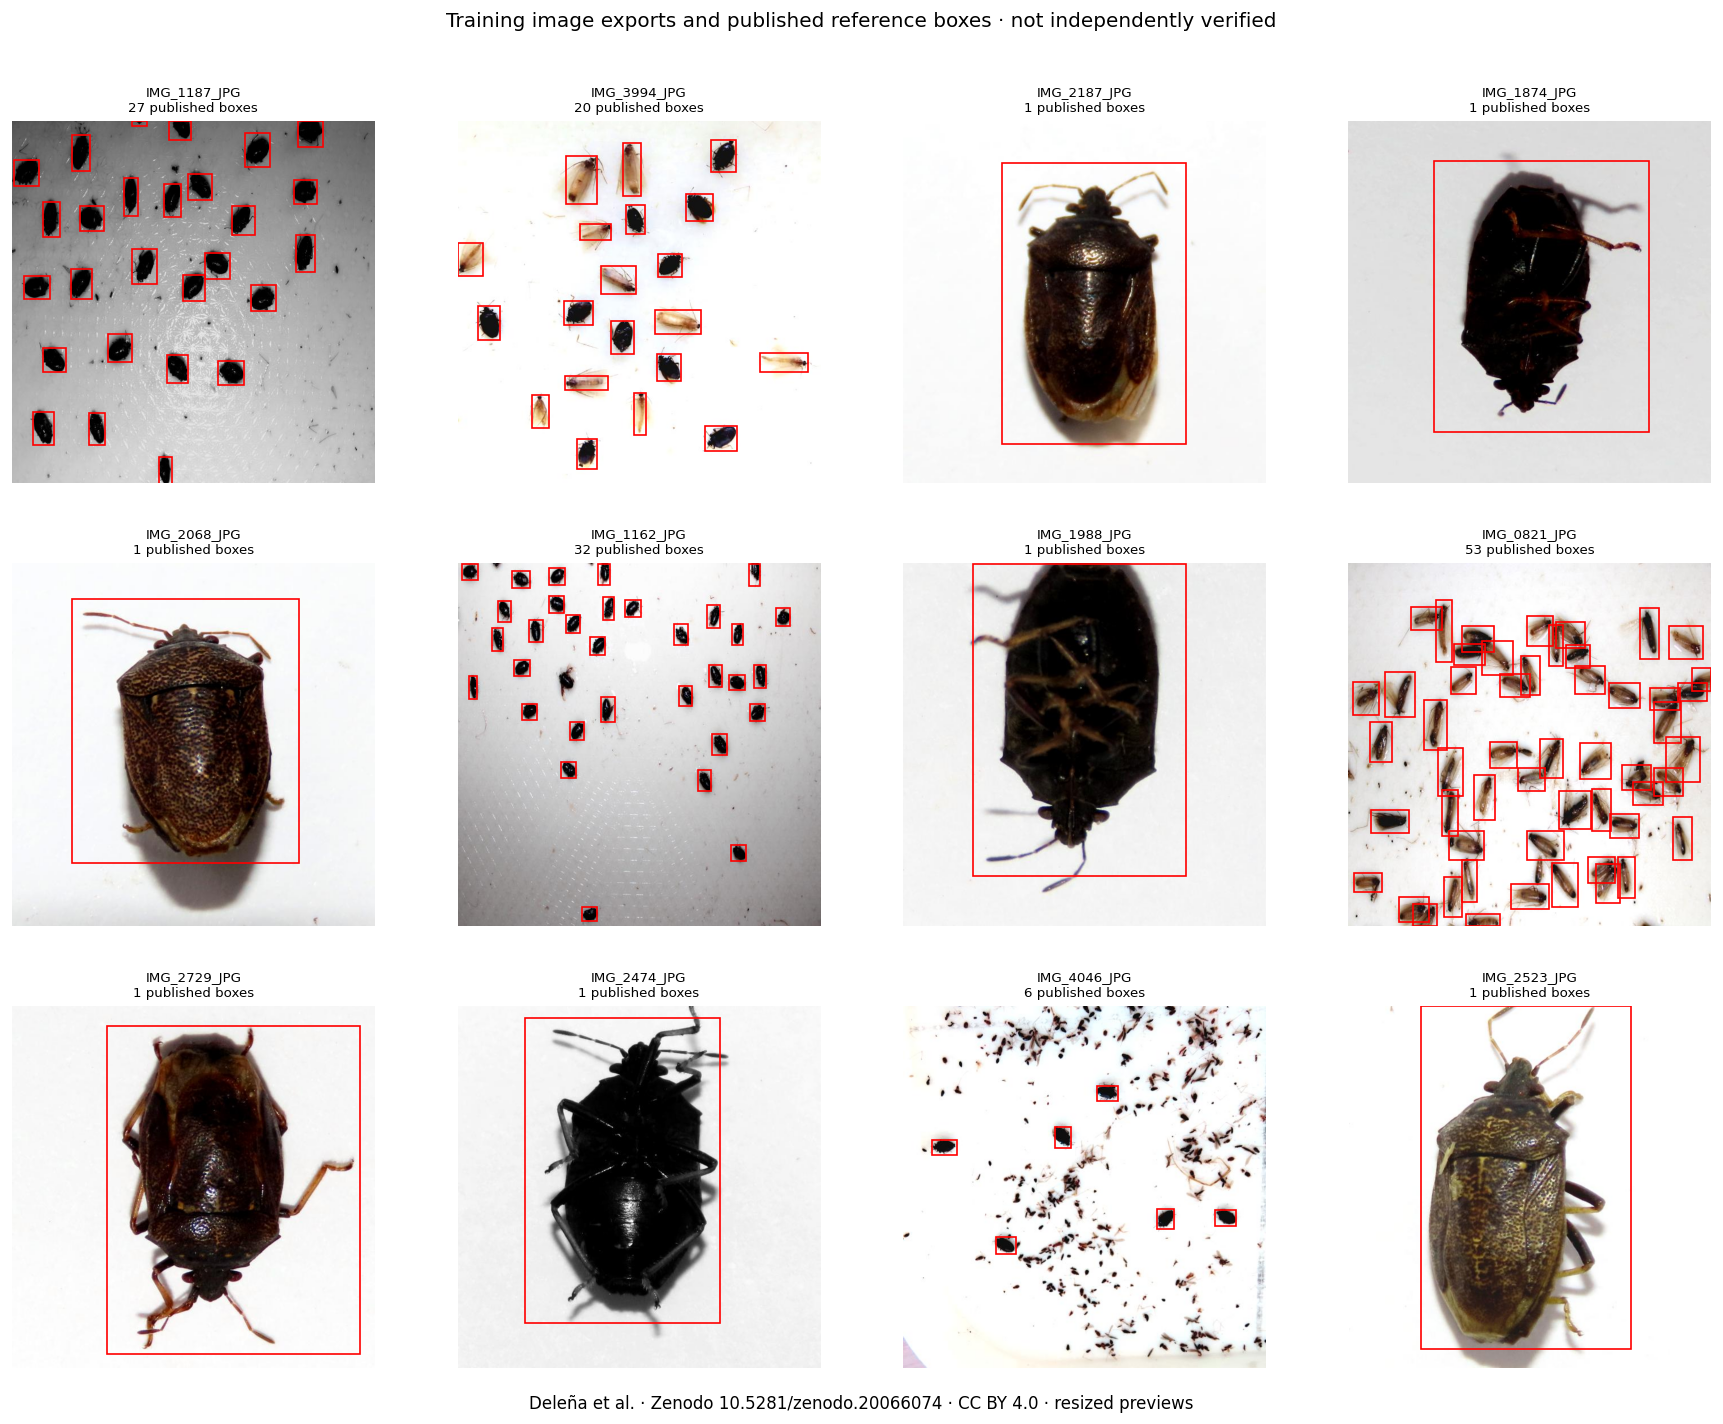

In [3]:
checked([PYTHON, '-c', "import json; from pathlib import Path; from rice_assets import prepare_images; root=Path('.'); load=lambda name: json.loads((root/name).read_text(encoding='utf-8')); print(prepare_images(root, load('data_manifest.json'), load('mirror.json')))"], cwd=ROOT)
run('prepare')
table('sample_summary.csv')
table('audit_gates.csv')
table('split_manifest.csv')
figures('prepare')

## 3. Reference crops and representation baselines
**Input:** crops reconstructed from published reference boxes. **Models:** majority class, RGB colour centroid, BioCLIP 2 and SigLIP 2. **Output:** validation classification metrics.

Crop evaluation assumes an object has already been located. It cannot measure missed insects. Common-name prompts and crop preprocessing are fixed before test inspection. RGB success can indicate background shortcuts; large confidence does not establish biological correctness.

The first figure shows what the classifier receives: training crops cut from reference boxes, labelled with their published species. Small crops carry little detail.

**Predict:** will the biodiversity representation outperform the general representation? Compare macro-F1 and class support rather than confidence alone.

**How to read the result:** for each method, `accuracy` and `macro_f1` range from 0 to 1; `confusion` rows are reference species and columns predicted species (rice black bug first). The majority baseline's macro-F1 shows what "no information" looks like.

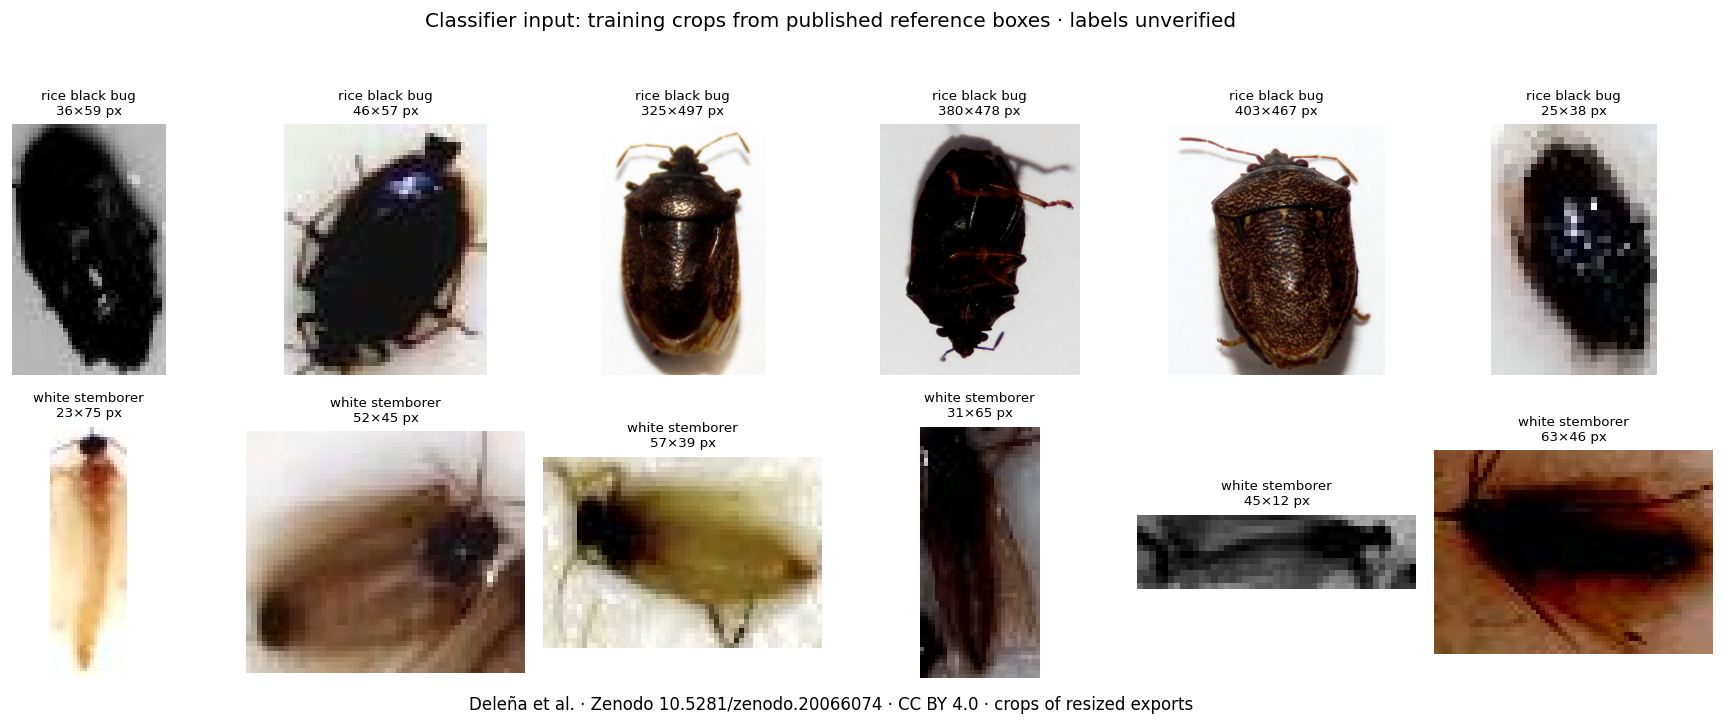

Running features — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/features.log
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
{
  "bioclip": {
    "accuracy": 0.9142857142857143,
    "macro_f1": 0.9127791068580542,
    "confusion": [
      [
        183,
        3
      ],
      [
        27,
        137
      ]
    ],
    "per_class": [
      {
        "species": "rice_black_bug",
        "precision": 0.8714285714285714,
        "recall": 0.9838709677419355,
        "f1": 0.9242424242424242,
        "support": 186
      },
      {
        "species": "white_stemborer",
        "precision": 0.9785714285714285,
        "recall": 0.8353658536585366,
        "f1": 0.9013157894736842,
      

/content/outputs/rice_pest/a99cf9b454f8/outputs/validation_crops.json

In [4]:
figures('crops')
run('features')
record('validation_crops.json')

## 4. Adapt only the species head
The BioCLIP image tower stays frozen. A small linear head starts from text embeddings and trains for at most 20 epochs. Epoch zero is eligible; minimum validation cross-entropy selects the checkpoint, with earlier ties.

**Notice:** whether validation loss improves with training loss. More epochs are not automatically better. The test split is not used to choose this head.

Running classifier — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/classifier.log
[
  {
    "epoch": 0,
    "validation_cross_entropy": 0.21322102844715118,
    "training_cross_entropy": 0.319577157497406
  },
  {
    "epoch": 1,
    "validation_cross_entropy": 0.2071920782327652,
    "training_cross_entropy": 0.3108231723308563
  },
  {
    "epoch": 2,
    "validation_cross_entropy": 0.20167799293994904,
    "training_cross_entropy": 0.30270496010780334
  },
  {
    "epoch": 3,
    "validation_cross_entropy": 0.19689810276031494,
    "training_cross_entropy": 0.29554539918899536
  },
  {
    "epoch": 4,
    "validation_cross_entropy": 0.19259709119796753,
    "training_cross_entropy": 0.28900349140167236
  },
  {
    "epoch": 5,
    "validation_cross_entropy": 0.1889556497335434,
    "training_cross_entropy": 0.2833585739135742
  },
  {
    "epoch": 6,
    "validation_cross_entropy": 0.1859355866909027,
    "training_cross_entropy": 0.2785908877849579
  },

/content/outputs/rice_pest/a99cf9b454f8/outputs/classifier_history.json

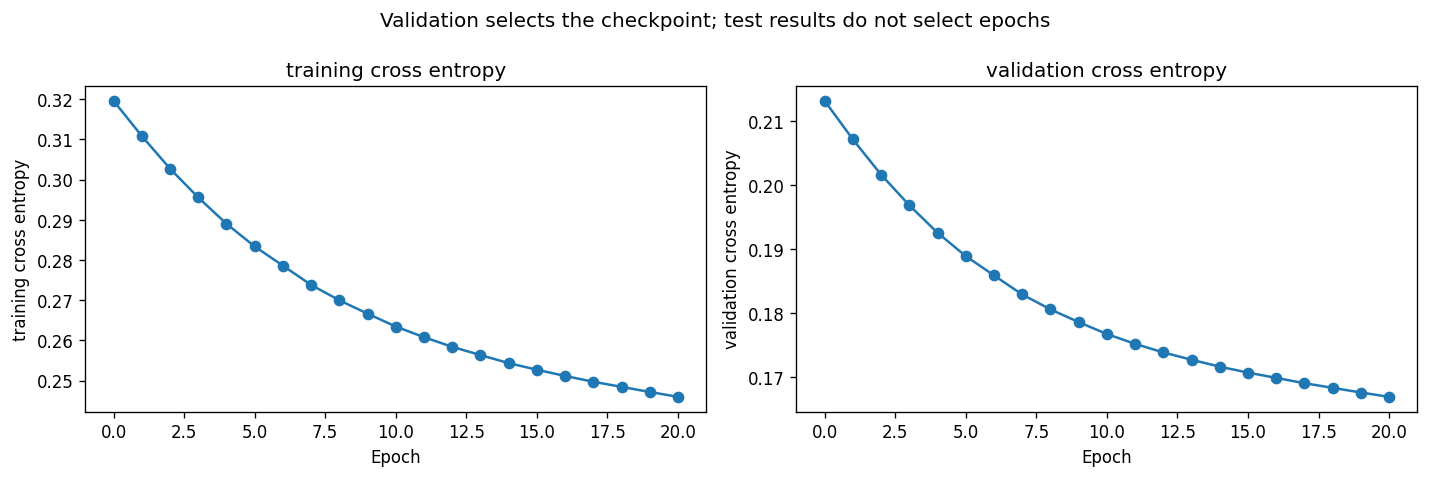

In [5]:
run('classifier')
record('classifier_history.json')
figures('classifier')

## 5. Adapt the detector
DETR starts from COCO weights, but its new target-pest head is untrained. Epoch zero is an untrained-head baseline, not zero-shot pest detection. The ResNet backbone stays frozen while transformer and detection heads train. The bounded recipe uses gradient accumulation and validation AP50 checkpoint selection.

**Input:** complete image exports and their boxes. **Output:** ranked target-pest boxes. The detector cannot represent more than 100 objects per image. We do not truncate reference boxes to make a metric look better.

**Notice:** validation localisation quality and the chosen epoch. Poor adaptation remains a reportable result.

Running detector — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/detector.log
Some weights of the model checkpoint at /content/outputs/rice_pest/a99cf9b454f8/weights/detr were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification

/content/outputs/rice_pest/a99cf9b454f8/outputs/detector_history.json

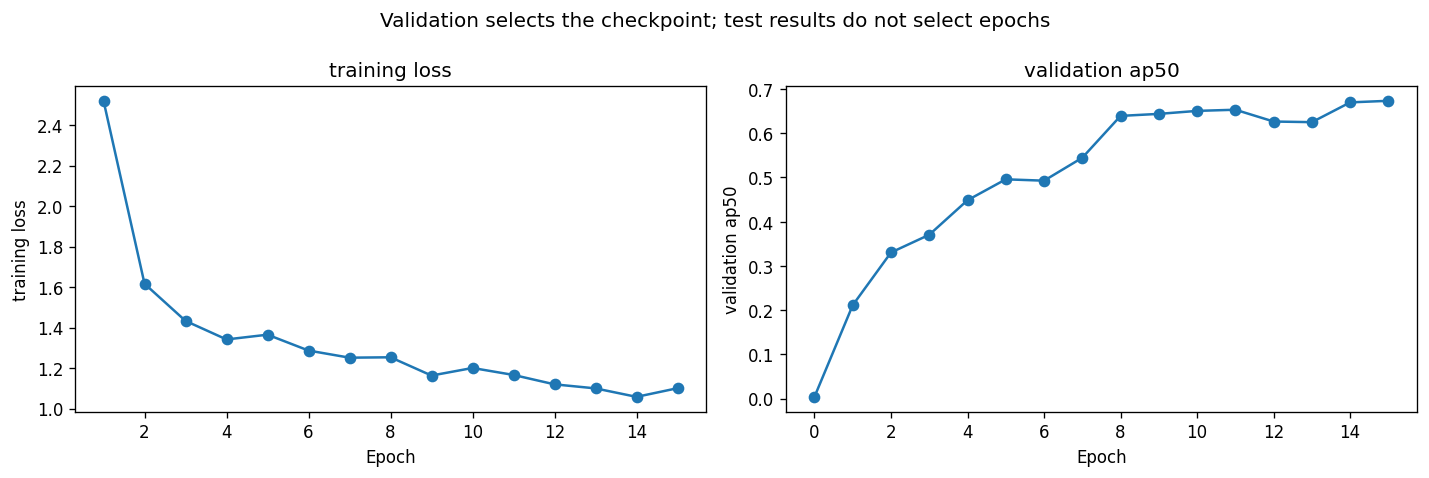

In [6]:
run('detector')
record('detector_history.json')
figures('detector')

## 6. Lock the composed policy
Checkpoint selection is finished. Choose the detection threshold on validation data to minimise per-image/per-species count MAE, with higher-threshold ties. Separately choose a species-score-margin review policy.

Every retained detection contributes to the raw count. Review flags create unresolved work; they do not make insects disappear. A missed detection cannot be referred by the classifier. Scores are not calibrated probabilities or operational pest-alert thresholds.

The review policy first looks for the margin with the highest coverage that keeps at least 80% selective accuracy while accepting at least 50% of validation crops. If no margin reaches that target, it falls back to the most accurate margin, then the widest coverage. The output states which rule applied; a fallback can send many detections to review.

**Predict:** will the full pipeline match the reference-crop classifier? Name a failure the crop classifier cannot expose.

In [7]:
run('policy')
record('selected_policy.json')
locked = json.loads((ROOT / 'outputs' / 'selected_policy.json').read_text(encoding='utf-8'))
print('Detector threshold:', locked['detector_threshold'])
print('Review margin:', locked['review_margin'], '|', locked['review_selection_rule'])
print('Validation coverage / selective accuracy:', locked['review_validation_coverage'], '/', locked['review_validation_accuracy'])

Running policy — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/policy.log
Some weights of the model checkpoint at /content/outputs/rice_pest/a99cf9b454f8/weights/detr were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification mod

/content/outputs/rice_pest/a99cf9b454f8/outputs/selected_policy.json

Detector threshold: 0.9
Review margin: 0.005233716860690629 | target met: highest coverage with >=80% selective accuracy and >=50% coverage
Validation coverage / selective accuracy: 1.0 / 0.9285714285714286


## 7. Reveal the held-out benchmark
The primary metric averages absolute count error over images and both species, including zero counts. Compare it with the training-mean and zero-count baselines. Oracle localisation uses published boxes; it is not a deployable system or a guaranteed mathematical upper bound because counting errors can cancel.

Inspect crop macro-F1, detection AP, misses, spurious/duplicate boxes and wrong-species matches. Bootstrap intervals resample source families; they do not establish independent capture events, complete annotations, pretraining independence or wider field performance. Two-class top-2 accuracy would be uninformative and is not a headline metric.

**Where does count error enter?** After the metrics, three tables trace it:
1. **Error summary**, per species: `reference = correct + wrong_out + missed` and `raw = correct + wrong_in + spurious`. `wrong_out` is a reference insect of this species labelled as the other; `wrong_in` is the reverse. `accepted` and `referred` split the raw count by the review policy.
2. **Matched-species confusion**: rows are reference species, columns predicted species; the last column counts missed references, and the last row counts spurious predictions.
3. **Example panels**: one held-out photograph per error category (misses, spurious, wrong species, success). Each title says which category it illustrates and gives its counts. Green boxes are correct matches, magenta boxes are wrong-species matches (the white dashed box is the reference), dashed blue boxes are missed references, and orange boxes are spurious predictions. Each error box carries a `#tag`; the table after the panels lists each tag's reference species, predicted species, **detector score**, **species score**, margin and review state. The last table reconciles each example's per-species counts.

If a category is absent from the held-out split, the inventory says so; no example is manufactured.

Running evaluate — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/evaluate.log
Some weights of the model checkpoint at /content/outputs/rice_pest/a99cf9b454f8/weights/detr were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification

| system | images | image_species_pairs | mae | bias | exact_count_rate | all_species_exact_image_rate | total_target_mae |
| --- | --- | --- | --- | --- | --- | --- | --- |
| training_mean | 40 | 80 | 8.123124999999998 | 1.4124999999999992 | 0.0 | 0.0 | 13.025 |
| zero_count | 40 | 80 | 5.6875 | -5.6875 | 0.4375 | 0.0 | 11.375 |
| oracle_bioclip | 40 | 80 | 0.925 | 0.0 | 0.675 | 0.675 | 0.0 |
| oracle_adapted | 40 | 80 | 0.65 | 0.0 | 0.725 | 0.725 | 0.0 |
| detector_majority | 40 | 80 | 6.95 | -0.125 | 0.4 | 0.025 | 3.65 |
| detector_bioclip | 40 | 80 | 2.125 | -0.125 | 0.35 | 0.0 | 3.65 |
| detector_adapted | 40 | 80 | 2.05 | -0.125 | 0.3625 | 0.0 | 3.65 |

Rows: 7 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/metrics.csv

{
  "bioclip": {
    "accuracy": 0.9186813186813186,
    "macro_f1": 0.9134362739804918,
    "confusion": [
      [
        265,
        6
      ],
      [
        31,
        153
      ]
    ],
    "per_class": [
      {
        "species": "rice_black_bug",
        "precision": 0.8952702702702703,
        "recall": 0.977859778597786,
        "f1": 0.9347442680776015,
        "support": 271
      },
      {
        "species": "white_stemborer",
        "precision": 0.9622641509433962,
        "recall": 0.8315217391304348,
        "f1": 0.892128279883382,
        "support": 184
      }
    ]
  },
  "adapted": {
    "accuracy": 0.9428571428571428,
    "macro_f1": 0.9404761904761905,
    "confusion": [
      [
        260,
        11
      ],
      [
        15,
        169
      ]
    ],
    "per_class": [
      {
        "species": "rice_black_bug",
        "precision": 0.9454545454545454,
        "recall": 0.959409594095941,
        "f1": 0.9523809523809523,
        "support": 271
    

...

Rows: 3 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/matched_species_confusion.csv

| image_id | capture_group_id | species | reference | raw | accepted | unresolved_total | training_mean |
| --- | --- | --- | --- | --- | --- | --- | --- |
| rice_00ff28b138a6f576 | IMG_1910_JPG | rice_black_bug | 1 | 0 | 0 | 0 | 5.941666666666666 |
| rice_00ff28b138a6f576 | IMG_1910_JPG | white_stemborer | 0 | 0 | 0 | 0 | 8.258333333333333 |
| rice_015e2132aff2ed5f | 20251107_160252_jpg | rice_black_bug | 0 | 0 | 0 | 0 | 5.941666666666666 |
| rice_015e2132aff2ed5f | 20251107_160252_jpg | white_stemborer | 12 | 1 | 1 | 0 | 8.258333333333333 |
| rice_045099d9eaa116bd | IMG_2379_JPG | rice_black_bug | 1 | 0 | 0 | 0 | 5.941666666666666 |
| rice_045099d9eaa116bd | IMG_2379_JPG | white_stemborer | 0 | 0 | 0 | 0 | 8.258333333333333 |
| rice_089ba40dac04ce61 | 6273997143085354522_jpg | rice_black_bug | 6 | 6 | 6 | 0 | 5.941666666666666 |
| rice_089ba40dac04ce61 | 6273997143085354522_jpg | white_stemborer | 6 | 4 | 4 | 0 | 8.258333333333333 |
| rice_0a7e8d9e71ba934e | IMG_2453_JPG | rice_black_bug | 1 | 0 | 0 | 0 | 5.941666666666666 |
| rice_0a7e8d9e71ba934e | IMG_2453_JPG | white_stemborer | 0 | 0 | 0 | 0 | 8.258333333333333 |
| rice_0b235e3cccc93131 | IMG_4151_JPG | rice_black_bug | 0 | 1 | 1 | 0 | 5.941666666666666 |
| rice_0b235e3cccc93131 | IMG_4151_JPG | white_stemborer | 10 | 18 | 18 | 0 | 8.258333333333333 |
| rice_0cede29efc7af87c | IMG_1077_JPG | rice_black_bug | 0 | 7 | 7 | 0 | 5.941666666666666 |
| rice_0cede29efc7af87c | IMG_1077_JPG | white_stemborer | 11 | 20 | 20 | 0 | 8.258333333333333 |
| rice_0cfde140bf5bc257 | IMG_2213_JPG | rice_black_bug | 1 | 0 | 0 | 0 | 5.941666666666666 |
| rice_0cfde140bf5bc257 | IMG_2213_JPG | white_stemborer | 0 | 0 | 0 | 0 | 8.258333333333333 |

Rows: 80 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/counts.csv

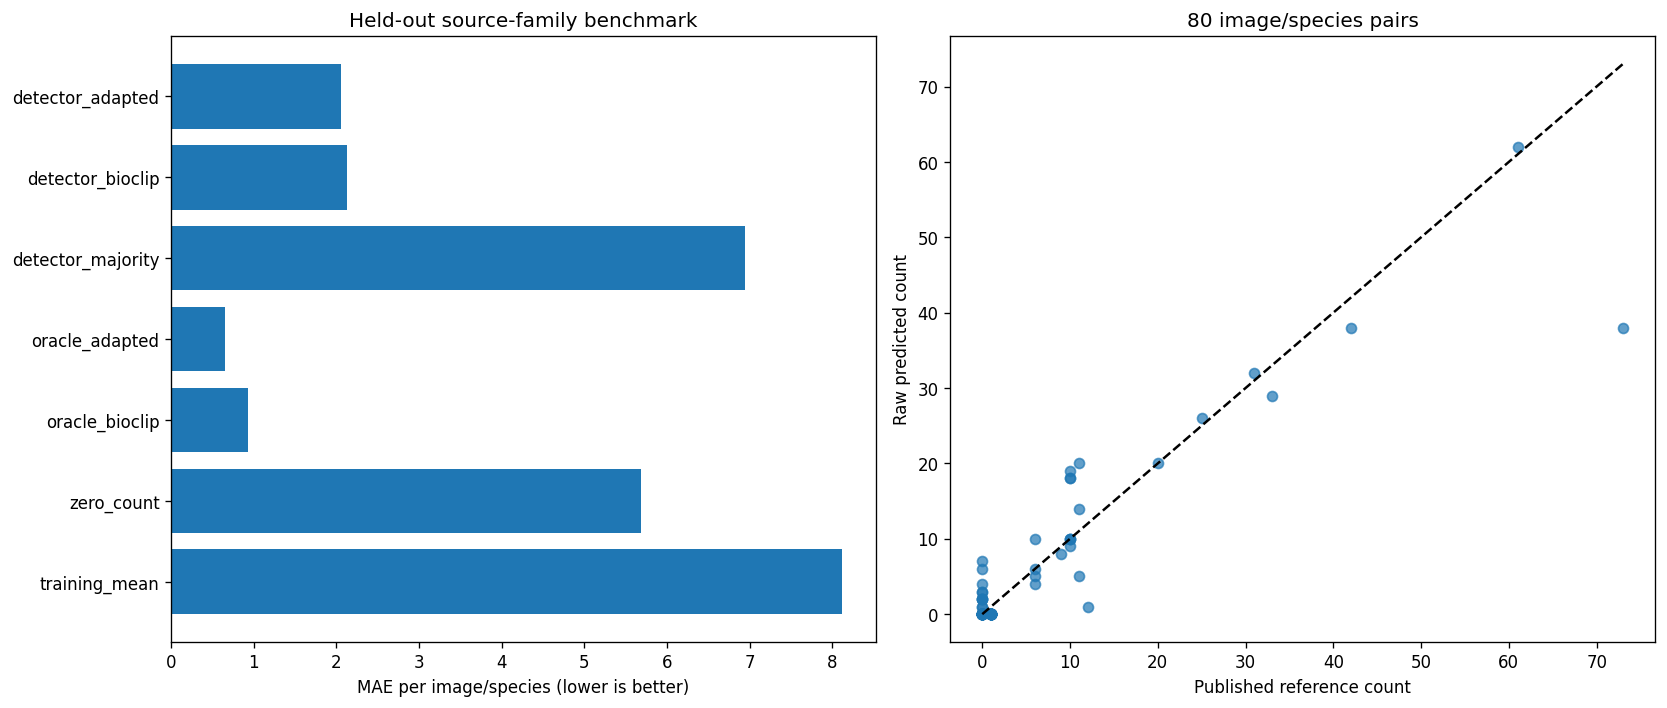

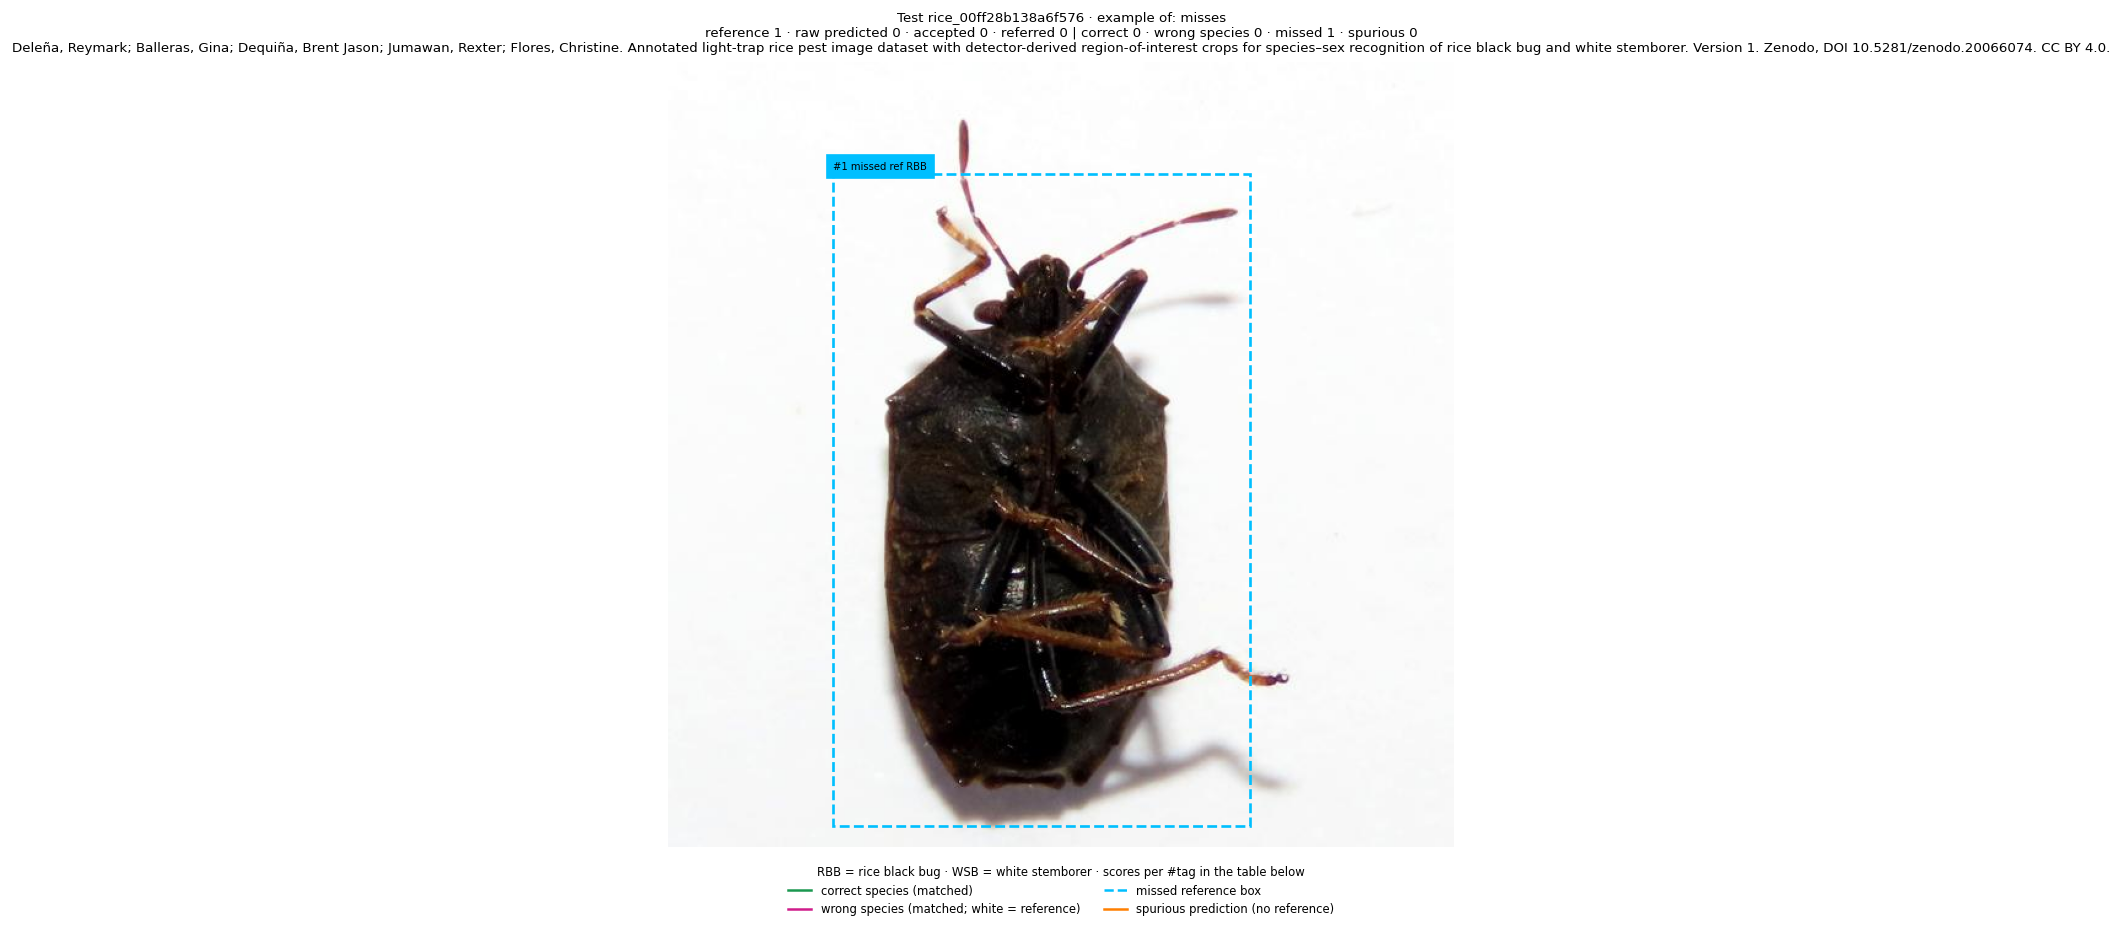

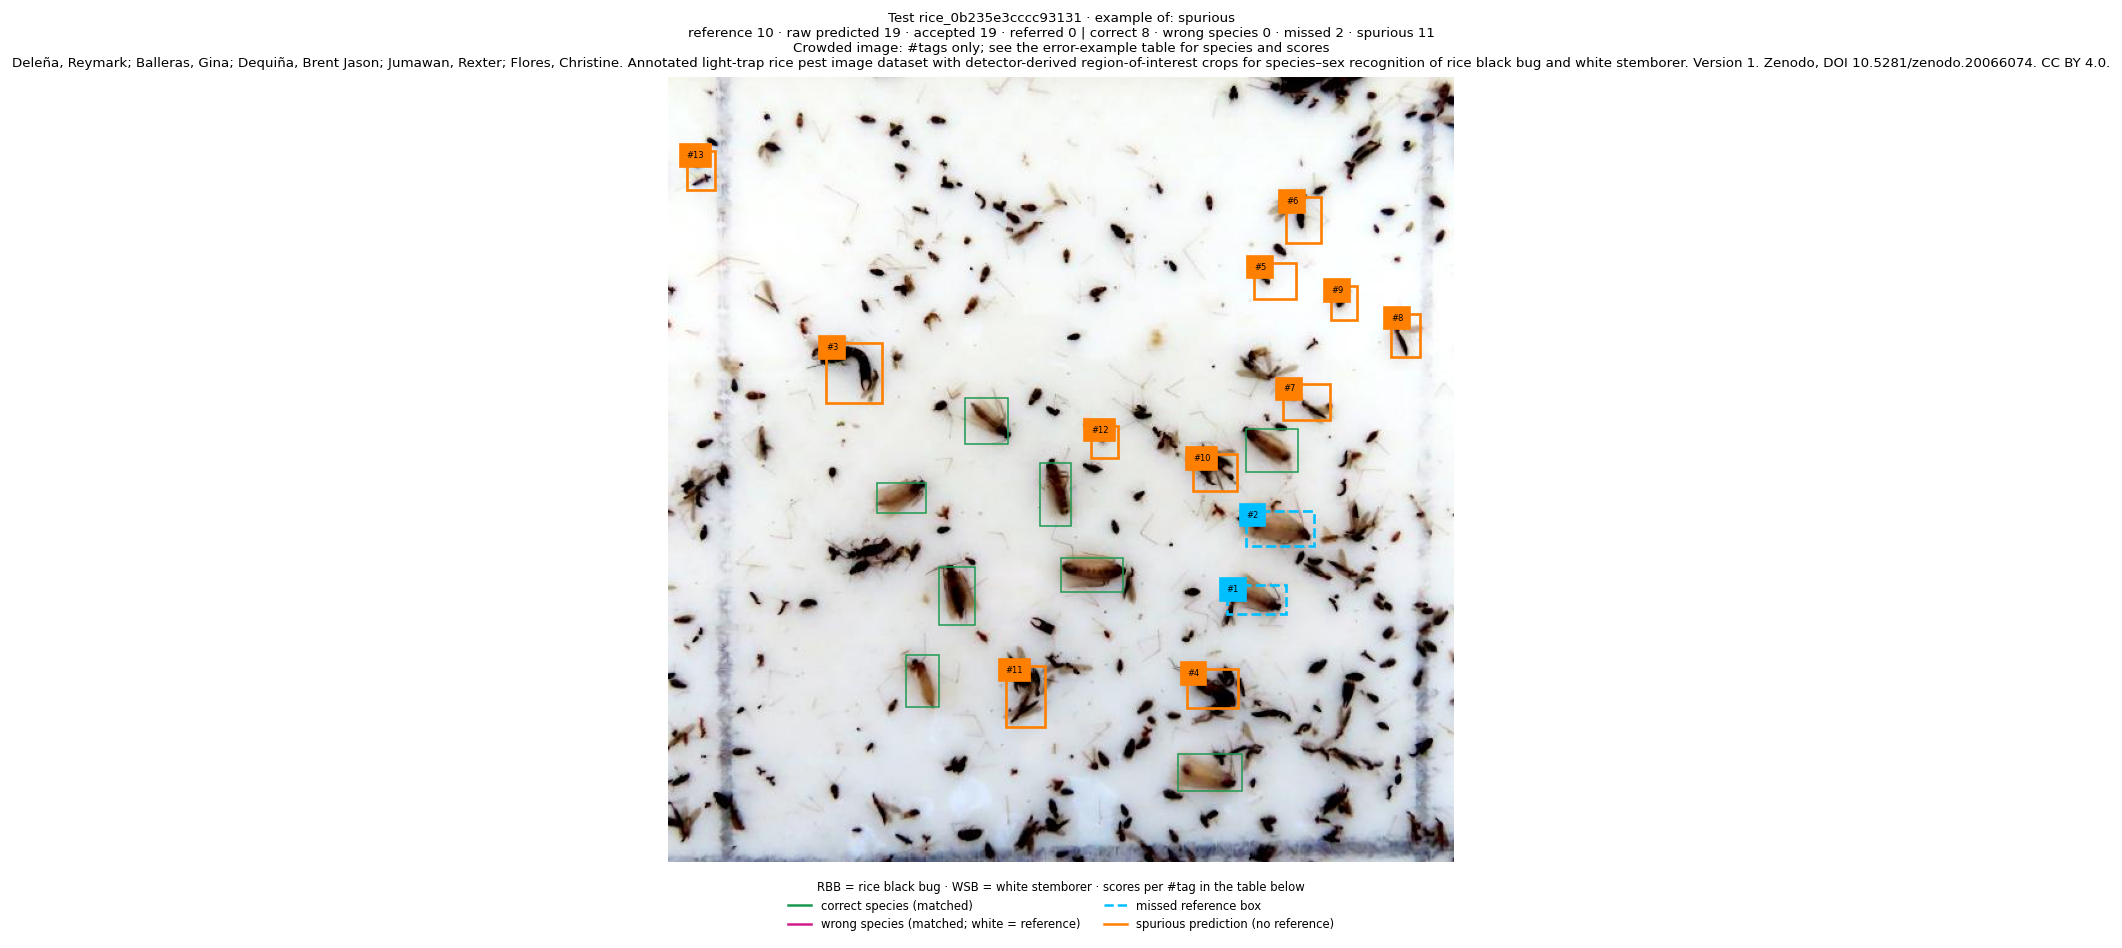

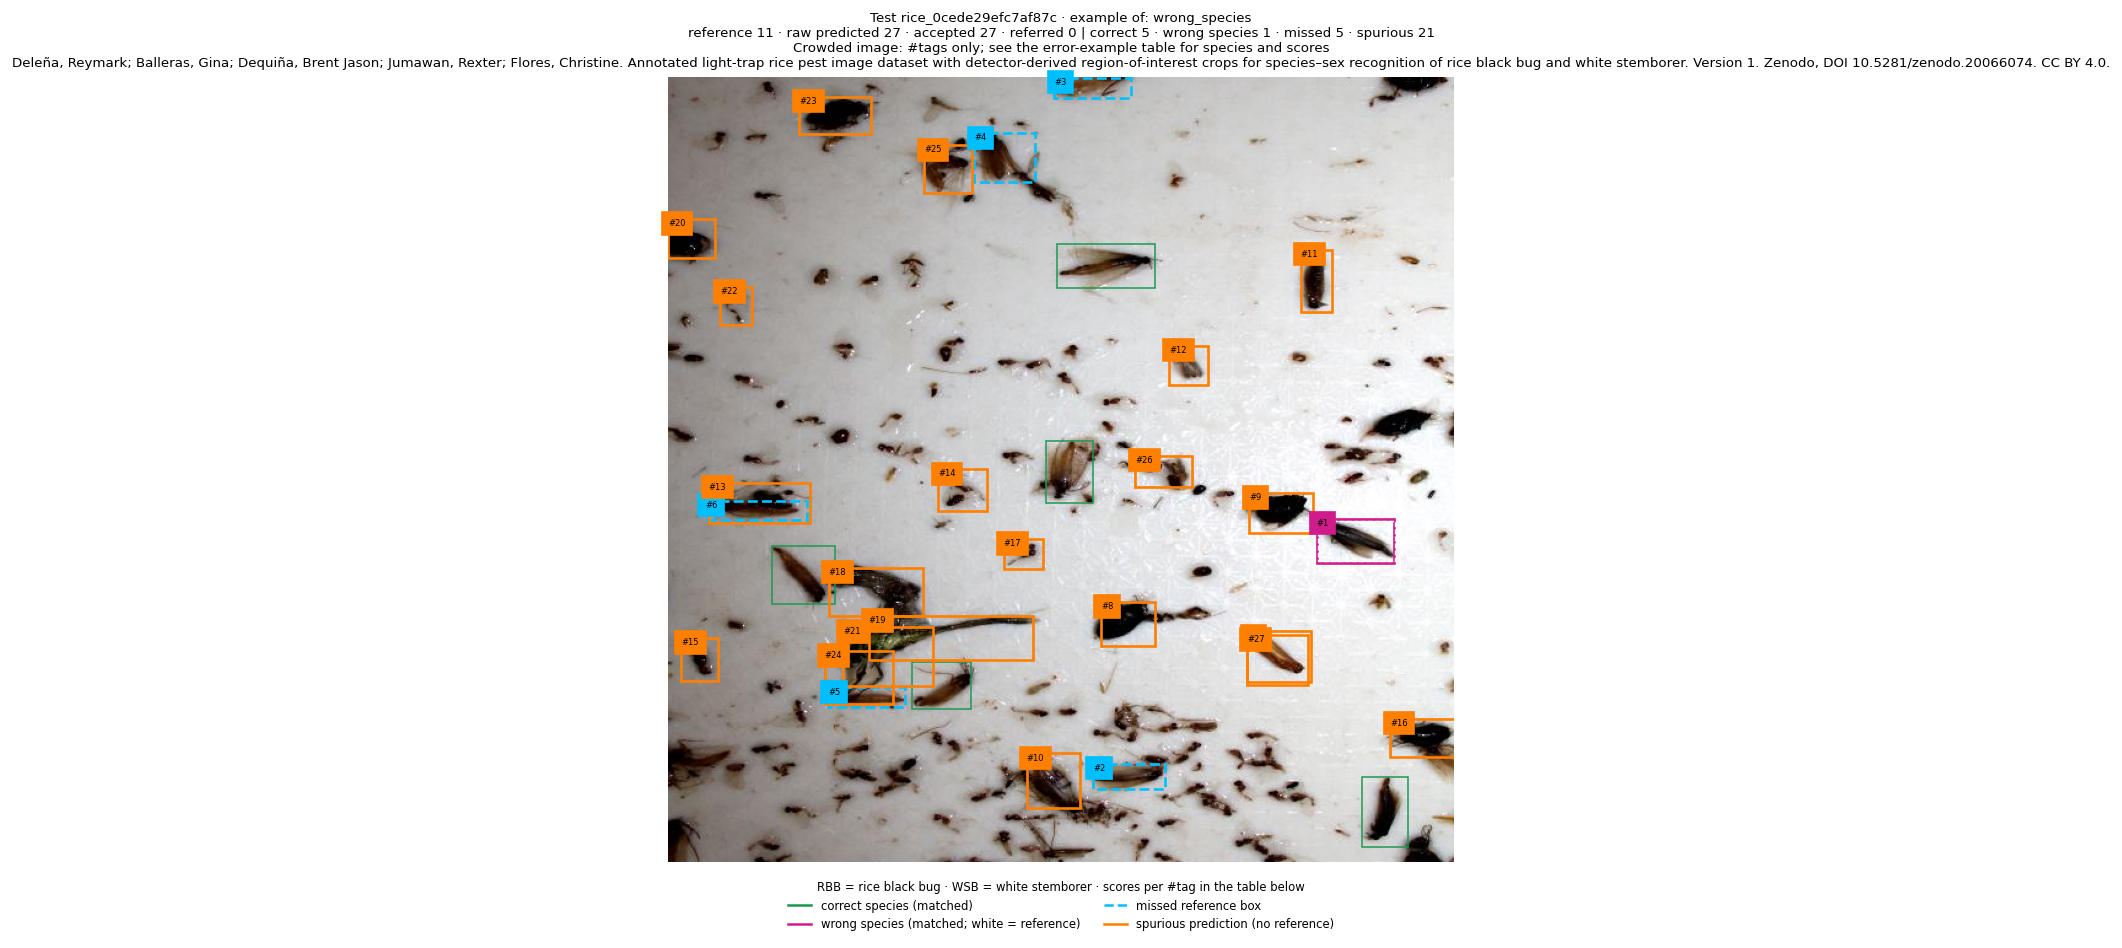

{
  "selected": {
    "misses": "rice_00ff28b138a6f576",
    "spurious": "rice_0b235e3cccc93131",
    "wrong_species": "rice_0cede29efc7af87c"
  },
  "absent_categories": [
    "success"
  ],
  "note": "An absent category was not found in the held-out split; none is manufactured."
}


/content/outputs/rice_pest/a99cf9b454f8/outputs/error_panel_inventory.json

| panel_tag | image_id | outcome | reference_species | predicted_species | detector_score | species_score | species_margin | review | iou |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 | rice_00ff28b138a6f576 | missed | rice_black_bug |  |  |  |  |  |  |
| 1 | rice_0b235e3cccc93131 | missed | white_stemborer |  |  |  |  |  |  |
| 2 | rice_0b235e3cccc93131 | missed | white_stemborer |  |  |  |  |  |  |
| 3 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9568 | 0.99 | 0.98 | accepted |  |
| 4 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9514 | 0.9941 | 0.9882 | accepted |  |
| 5 | rice_0b235e3cccc93131 | spurious |  | rice_black_bug | 0.9484 | 0.8314 | 0.6628 | accepted |  |
| 6 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9428 | 0.6208 | 0.2417 | accepted |  |
| 7 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9302 | 0.9874 | 0.9747 | accepted |  |
| 8 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9287 | 0.9997 | 0.9994 | accepted |  |
| 9 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9278 | 0.7531 | 0.5063 | accepted |  |
| 10 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9264 | 0.6371 | 0.2742 | accepted |  |
| 11 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9257 | 0.9992 | 0.9984 | accepted |  |
| 12 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9141 | 0.8421 | 0.6841 | accepted |  |
| 13 | rice_0b235e3cccc93131 | spurious |  | white_stemborer | 0.9039 | 0.7326 | 0.4652 | accepted |  |
| 1 | rice_0cede29efc7af87c | wrong_species | white_stemborer | rice_black_bug | 0.9782 | 0.8005 | 0.6011 | accepted | 0.874 |
| 2 | rice_0cede29efc7af87c | missed | white_stemborer |  |  |  |  |  |  |
| 3 | rice_0cede29efc7af87c | missed | white_stemborer |  |  |  |  |  |  |
| 4 | rice_0cede29efc7af87c | missed | white_stemborer |  |  |  |  |  |  |
| 5 | rice_0cede29efc7af87c | missed | white_stemborer |  |  |  |  |  |  |
| 6 | rice_0cede29efc7af87c | missed | white_stemborer |  |  |  |  |  |  |
| 7 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9817 | 0.9999 | 0.9999 | accepted |  |
| 8 | rice_0cede29efc7af87c | spurious |  | rice_black_bug | 0.9787 | 0.9852 | 0.9704 | accepted |  |
| 9 | rice_0cede29efc7af87c | spurious |  | rice_black_bug | 0.9765 | 0.9933 | 0.9866 | accepted |  |
| 10 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9747 | 0.9322 | 0.8643 | accepted |  |
| 11 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9745 | 0.9383 | 0.8767 | accepted |  |
| 12 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9737 | 0.9825 | 0.965 | accepted |  |
| 13 | rice_0cede29efc7af87c | spurious |  | rice_black_bug | 0.9652 | 0.5265 | 0.053 | accepted |  |
| 14 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9622 | 0.9995 | 0.9989 | accepted |  |
| 15 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9607 | 0.7549 | 0.5098 | accepted |  |
| 16 | rice_0cede29efc7af87c | spurious |  | rice_black_bug | 0.9605 | 0.9545 | 0.909 | accepted |  |
| 17 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9586 | 0.9999 | 0.9998 | accepted |  |
| 18 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9572 | 0.7382 | 0.4765 | accepted |  |
| 19 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9493 | 0.999 | 0.9979 | accepted |  |
| 20 | rice_0cede29efc7af87c | spurious |  | rice_black_bug | 0.9477 | 0.9853 | 0.9706 | accepted |  |
| 21 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9437 | 0.9959 | 0.9918 | accepted |  |
| 22 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9273 | 0.9616 | 0.9232 | accepted |  |
| 23 | rice_0cede29efc7af87c | spurious |  | rice_black_bug | 0.9272 | 0.9807 | 0.9613 | accepted |  |
| 24 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9113 | 0.9986 | 0.9973 | accepted |  |
| 25 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9095 | 0.998 | 0.9961 | accepted |  |
| 26 | rice_0cede29efc7af87c | spurious |  | white_stemborer | 0.9092 | 0.9995 | 0.9991 | accepted |  |

Rows: 41 (preview limited to 40 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/error_examples.csv

| image_id | species | reference | raw | accepted | referred | correct | wrong_in | wrong_out | missed | spurious |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rice_00ff28b138a6f576 | rice_black_bug | 1 | 0 | 0 | 0 | 0 | 0 | 0 | 1 | 0 |
| rice_00ff28b138a6f576 | white_stemborer | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 | 0 |
| rice_0b235e3cccc93131 | rice_black_bug | 0 | 1 | 1 | 0 | 0 | 0 | 0 | 0 | 1 |
| rice_0b235e3cccc93131 | white_stemborer | 10 | 18 | 18 | 0 | 8 | 0 | 0 | 2 | 10 |
| rice_0cede29efc7af87c | rice_black_bug | 0 | 7 | 7 | 0 | 0 | 1 | 0 | 0 | 6 |
| rice_0cede29efc7af87c | white_stemborer | 11 | 20 | 20 | 0 | 5 | 0 | 1 | 5 | 15 |

Rows: 6 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/error_example_counts.csv

In [8]:
run('evaluate')
table('metrics.csv')
record('test_crop_metrics.json')
record('detection_metrics.json')
record('bootstrap.json')
table('error_summary.csv')
table('matched_species_confusion.csv')
table('counts.csv')
figures('evaluate')
record('error_panel_inventory.json')
table('error_examples.csv', limit=40)
table('error_example_counts.csv')

## 8. Change one thing: the display threshold
Predict what a lower detector threshold will do to misses, spurious boxes and count MAE. The activity compares lower/canonical/higher settings with the same models. It is retrospective test analysis, not permission to replace the locked result with the best-looking test setting.

Canonical predictions and policy remain unchanged. Explain any error cancellation: a correct total can still contain missed and extra insects.

The second table follows one held-out photograph: the image whose raw count changes most across the three settings. For each setting and species it shows the reference count, the raw count and the stage errors, so you can see which errors a threshold change adds or removes.

Running activity — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/activity.log


| display_threshold | role | mae | missed | spurious | wrong_species | note |
| --- | --- | --- | --- | --- | --- | --- |
| 0.8 | lower | 2.8625 | 102 | 223 | 14 | Retrospective test illustration; canonical policy unchanged |
| 0.9 | canonical | 2.05 | 136 | 126 | 13 | Retrospective test illustration; canonical policy unchanged |
| 1.0 | higher | 5.6875 | 455 | 0 | 0 | Retrospective test illustration; canonical policy unchanged |

Rows: 3 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/activity_thresholds.csv

| image_id | display_threshold | role | species | reference | raw | missed | spurious | wrong_species |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| rice_1b3bff70af4223e5 | 0.8 | lower | rice_black_bug | 61 | 62 | 13 | 15 | 1 |
| rice_1b3bff70af4223e5 | 0.8 | lower | white_stemborer | 0 | 4 | 0 | 3 | 0 |
| rice_1b3bff70af4223e5 | 0.9 | canonical | rice_black_bug | 61 | 62 | 13 | 15 | 1 |
| rice_1b3bff70af4223e5 | 0.9 | canonical | white_stemborer | 0 | 2 | 0 | 1 | 0 |
| rice_1b3bff70af4223e5 | 1.0 | higher | rice_black_bug | 61 | 0 | 61 | 0 | 0 |
| rice_1b3bff70af4223e5 | 1.0 | higher | white_stemborer | 0 | 0 | 0 | 0 | 0 |

Rows: 6 (preview limited to 16 )


/content/outputs/rice_pest/a99cf9b454f8/outputs/activity_paired_counts.csv

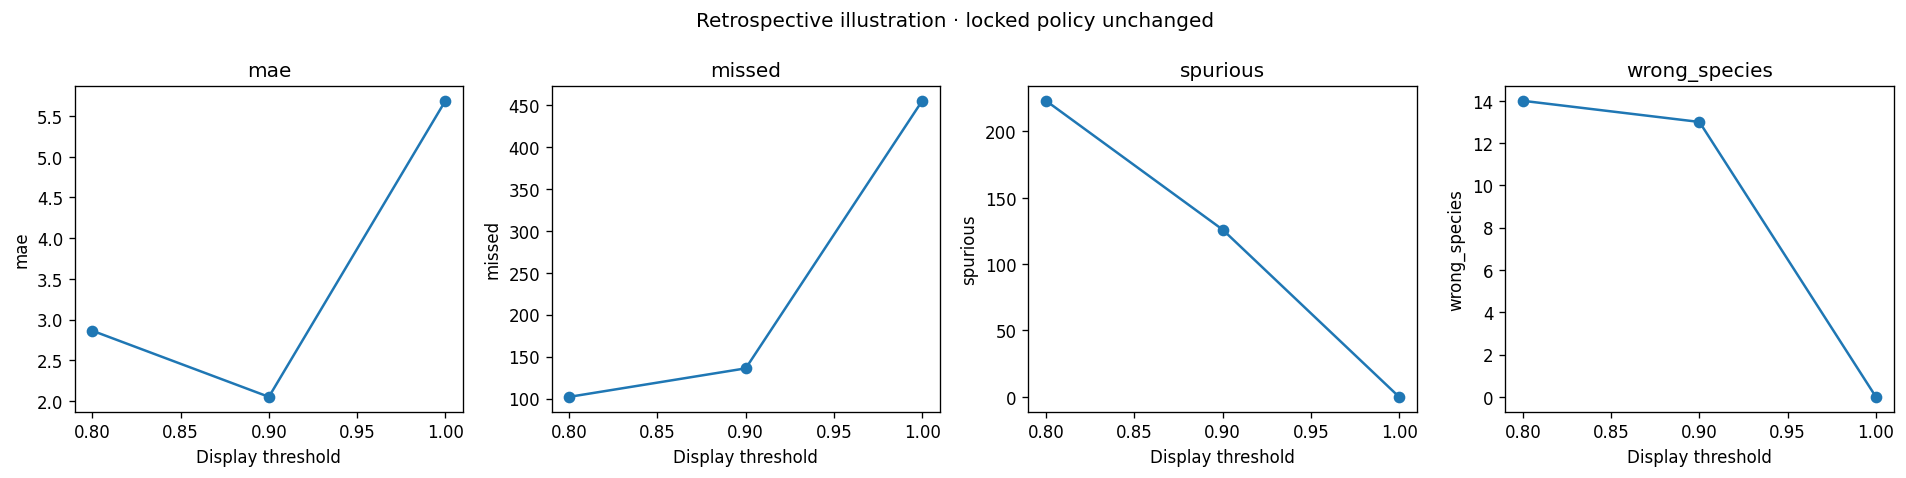

In [9]:
run('activity')
table('activity_thresholds.csv')
table('activity_paired_counts.csv')
figures('activity')

## 9. Export, reload and verify
Both adapters reload in a fresh process with pinned bases. Original held-out images are reprocessed; boxes, species, counts and review decisions must agree within declared tolerances. Hashes and class order must match before tensors are loaded.

The results archive includes derived evidence, attribution and the metric charts (learning curves, count comparison and threshold charts). Source photographs, photo previews and annotated panels are excluded by default. A passing archive check proves internal consistency, not independent biological validation.

In [10]:
run('reload')
record('verification.json')
run('report')
record('run_summary.json')
display(FileLink(str(ROOT / 'outputs' / 'results.zip')))

Running reload — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/reload.log
Some weights of the model checkpoint at /content/outputs/rice_pest/a99cf9b454f8/weights/detr were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification mod

/content/outputs/rice_pest/a99cf9b454f8/outputs/verification.json

Running report — retain this log if anything fails: /content/outputs/rice_pest/a99cf9b454f8/report.log
{
  "status": "Executed; maintainer review required for release",
  "scope": "exploratory_published_annotations",
  "policy_digest": "87b4689dced257a24d66bf62ed4d208c853e5ebecd6b62a4c3c666af635ccb7d",
  "limitations": [
    "Published annotations are not independently verified",
    "Capture independence and completeness are unverified",
    "Source-image/duplicate groups do not establish capture independence",
    "Pretraining overlap is unresolved",
    "Counts are image contents, not field abundance or intervention advice"
  ],
  "metrics": {
    "training_mean": {
      "images": 40,
      "image_species_pairs": 80,
      "mae": 8.123124999999998,
      "bias": 1.4124999999999992,
      "exact_count_rate": 0.0,
      "all_species_exact_image_rate": 0.0,
      "per_species_mae": [
        8.942916666666665,
        7.30333333333333
      ],
      "per_species_bias": [
        -0.83

/content/outputs/rice_pest/a99cf9b454f8/outputs/run_summary.json

/content/outputs/rice_pest/a99cf9b454f8/outputs/results.zip

## 10. Conclude with evidence
Complete this optional statement using the exported results:

> On [N] held-out image exports grouped into [G] source families, the composed pipeline achieved count MAE [value and interval], compared with [baseline]. Misses, extra detections and species errors contributed [evidence]. Changing only the display threshold showed [trade-off]. These results describe agreement with this dataset's published annotations; they do not establish independent-capture generalisation, field abundance, crop damage or intervention thresholds.

**Limitations to retain:** source-image grouping cannot resolve repeated specimens in different originals; exported images were stretched to 640×640; annotations and completeness were not independently verified; source capture locations are unavailable; the sample excludes over-capacity images; pretrained-model overlap is unresolved. Report absent error categories and zero detections honestly.

**Continue exploring:** compare the full [DETR](https://github.com/kurtvalcorza/detr-detection-pipeline), [BioCLIP 2](https://github.com/kurtvalcorza/bioclip2-biodiversity-pipeline) and [SigLIP 2](https://github.com/kurtvalcorza/siglip2-vision-language-pipeline) pipelines with the models available through [DIMER](https://training.dimer1.asti.dost.gov.ph/signin). A stronger follow-up would collect verified trap/session/specimen metadata and independently checked exhaustive annotations.

**Optional extension:** four-way species–sex classification requires separately verified sex labels and adequate independent support. It is not enabled by default. Completion records are not required submissions.

### Troubleshooting
If a source hash, model hash or receipt fails, preserve the log and stop; do not bypass the check. If T4 memory or time limits are exceeded, record actual use and revise the recipe before a new clean run. Do not silently lower sample size, epochs or image resolution. A model that fails to beat the count baseline is an informative result, not an execution error.

Sources: [dataset and citation](https://doi.org/10.5281/zenodo.20066074), [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/), [DIMER notebook standard](https://github.com/kurtvalcorza/ml-worker/blob/main/integrations/dimer/fleet-specs/NOTEBOOK_SPEC.md). Exact source/model identities and creator attribution are carried in the manifests.